<a href="https://colab.research.google.com/github/EstherYanLi/Customer-Churn-Prediction-using-updated-IBM-data/blob/main/Telco_Customer_churn_prediction_using_updated_IBM_data_Github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction
By Yan (Esther) Li

## Project Goal
This notebook aims to develop and evaluate machine learning models to accurately predict customer churn for a fictional Telco company. The primary objective is to maximize the identification of actual churners (high recall) to enable proactive retention strategies.

## Dataset
The analysis utilizes the IBM Cognos Telco customer churn dataset, which includes demographic information, service usage details, contract types, monthly charges, and churn status for 7043 customers in California.

## Methodology
The project involved several key stages:
1.  **Exploratory Data Analysis (EDA)**: Visualizing numerical and categorical variable distributions to understand differences between churned and non-churned customers.
2.  **Data Preprocessing**: Handling missing values, converting data types, encoding categorical features using OneHotEncoder, and standardizing numerical features.
3.  **Model Development & Evaluation**: Training and evaluating a range of classification models, including:
    *   Traditional Models: Logistic Regression, Support Vector Machine (SVM), and Random Forest Classifier.
    *   Advanced Models: XGBoost, LightGBM, and a Simple Neural Network.
    *   Model performance was assessed using confusion matrices, accuracy, precision, recall, F1- score and detailed classification reports, with a particular focus on recall for the churn class.

## Key Findings & Results
*   **Churn Drivers**: Churned customers typically exhibit shorter tenures, higher monthly charges, month-to-month contracts, lack of online security and tech support, and often use electronic check payment.
*   **Model Performance**: Advanced models (XGBoost, LightGBM, Neural Network) significantly outperformed traditional models in identifying churners (higher recall).
    *   **LightGBM**: Achieved the best balance of precision and recall (F1-score of 0.65 for churn) with a strong recall of 0.77.
    *   **Neural Network**: Demonstrated the highest recall (0.79) for churn, indicating it was most effective at identifying at-risk customers, though with a slightly lower precision (0.54) and F1-score (0.64).
    *   **Overall Accuracy**: All advanced models maintained competitive overall accuracy (75-77%).

## Business Impact & Recommendations
Based on the analysis, the following recommendations are made:
*   **Model Deployment**: Deploy the **LightGBM model** for real-time churn prediction due to its excellent balance of recall and precision, efficiency, and robustness. The Neural Network is an excellent alternative if maximizing recall is the absolute priority.
*   **Targeted Retention**: Focus retention efforts on customers flagged as high-risk by the model, tailoring interventions based on identified churn drivers.
*   **Continuous Monitoring**: Regularly monitor model performance and retrain with new data to adapt to evolving customer behaviors and market conditions.

By implementing these recommendations, the Telco company can proactively reduce customer churn, leading to improved customer lifetime value and sustained growth.

# 1.Introduction

In the new version of IBM Cognos data set 'The Telco customer churn' contains information about a fictional telco company that provided home phone and Internet services to 7043 customers in California in Q3 of 2019. It indicates which customers have left, stayed, or signed up for their service. This data set was enhanced to provide a wider narrative. Multiple important demographics are included for each customer, as well as a Churn Score and Customer Lifetime Value (CLTV) index.


Telco customer churn (11.1.3+):
https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113


## 1.1 Explaination of important variables

CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Tenure in Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Satisfaction Score: A customer’s overall satisfaction rating of the company from 1 (Very Unsatisfied) to 5 (Very Satisfied).

Satisfaction Score Label: Indicates the text version of the score (1-5) as a text string.

Customer Status: Indicates the status of the customer at the end of the quarter: Churned, Stayed, or Joined

Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.

# 2.Importing librabries




In [ ]:
# Install scikit-learn
!pip install scikit-learn

# Load libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical computations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns  # For advanced data visualization

from sklearn import preprocessing, model_selection, metrics  # For machine learning
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # For preprocessing data
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For evaluating model performance

from sklearn.linear_model import LogisticRegression  # For logistic regression
from sklearn.svm import SVC # For SVC
from sklearn.ensemble import RandomForestClassifier  # For random forest classification

## 2.1 Setting Random Seeds for Reproducibility

In [ ]:
# Set random seeds for reproducibility
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("Random seeds set for NumPy, random, and TensorFlow.")

Random seeds set for NumPy, random, and TensorFlow.


# 3.Data loading

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Read the file from Google Drive
df = pd.read_csv("/content/drive/My Drive/Work/Colab Notebooks/Dataset/Copy of Telco_customer_churn.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 4.Exploratory data analysis EDA

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

*We can see that 'Total charges' is object which should be converted to floating data type.*

In [ ]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
# Statistical summary
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
# Check missing data
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


We can see that Churn Reason has 5174 missing data

In [ ]:
# Understand Why 'Churn Reason' has 5174 missing data, Check the Relationship Between Churn and Churn Reason
# Cross-tabulate 'Churn Label' and 'Churn Reason' missingness
print(pd.crosstab(df['Churn Label'], df['Churn Reason'].isnull(), margins=True))

Churn Reason  False  True   All
Churn Label                    
No                0  5174  5174
Yes            1869     0  1869
All            1869  5174  7043


"Churn Reason" is structurally missing for retained customers (Churn="No"), creating data leakage since missingness itself reveals customer status. We recommend remove the column to eliminates leakage risk.

# 5.Data Visualization

## 5.1 Plot numerical data with respect to churn lable

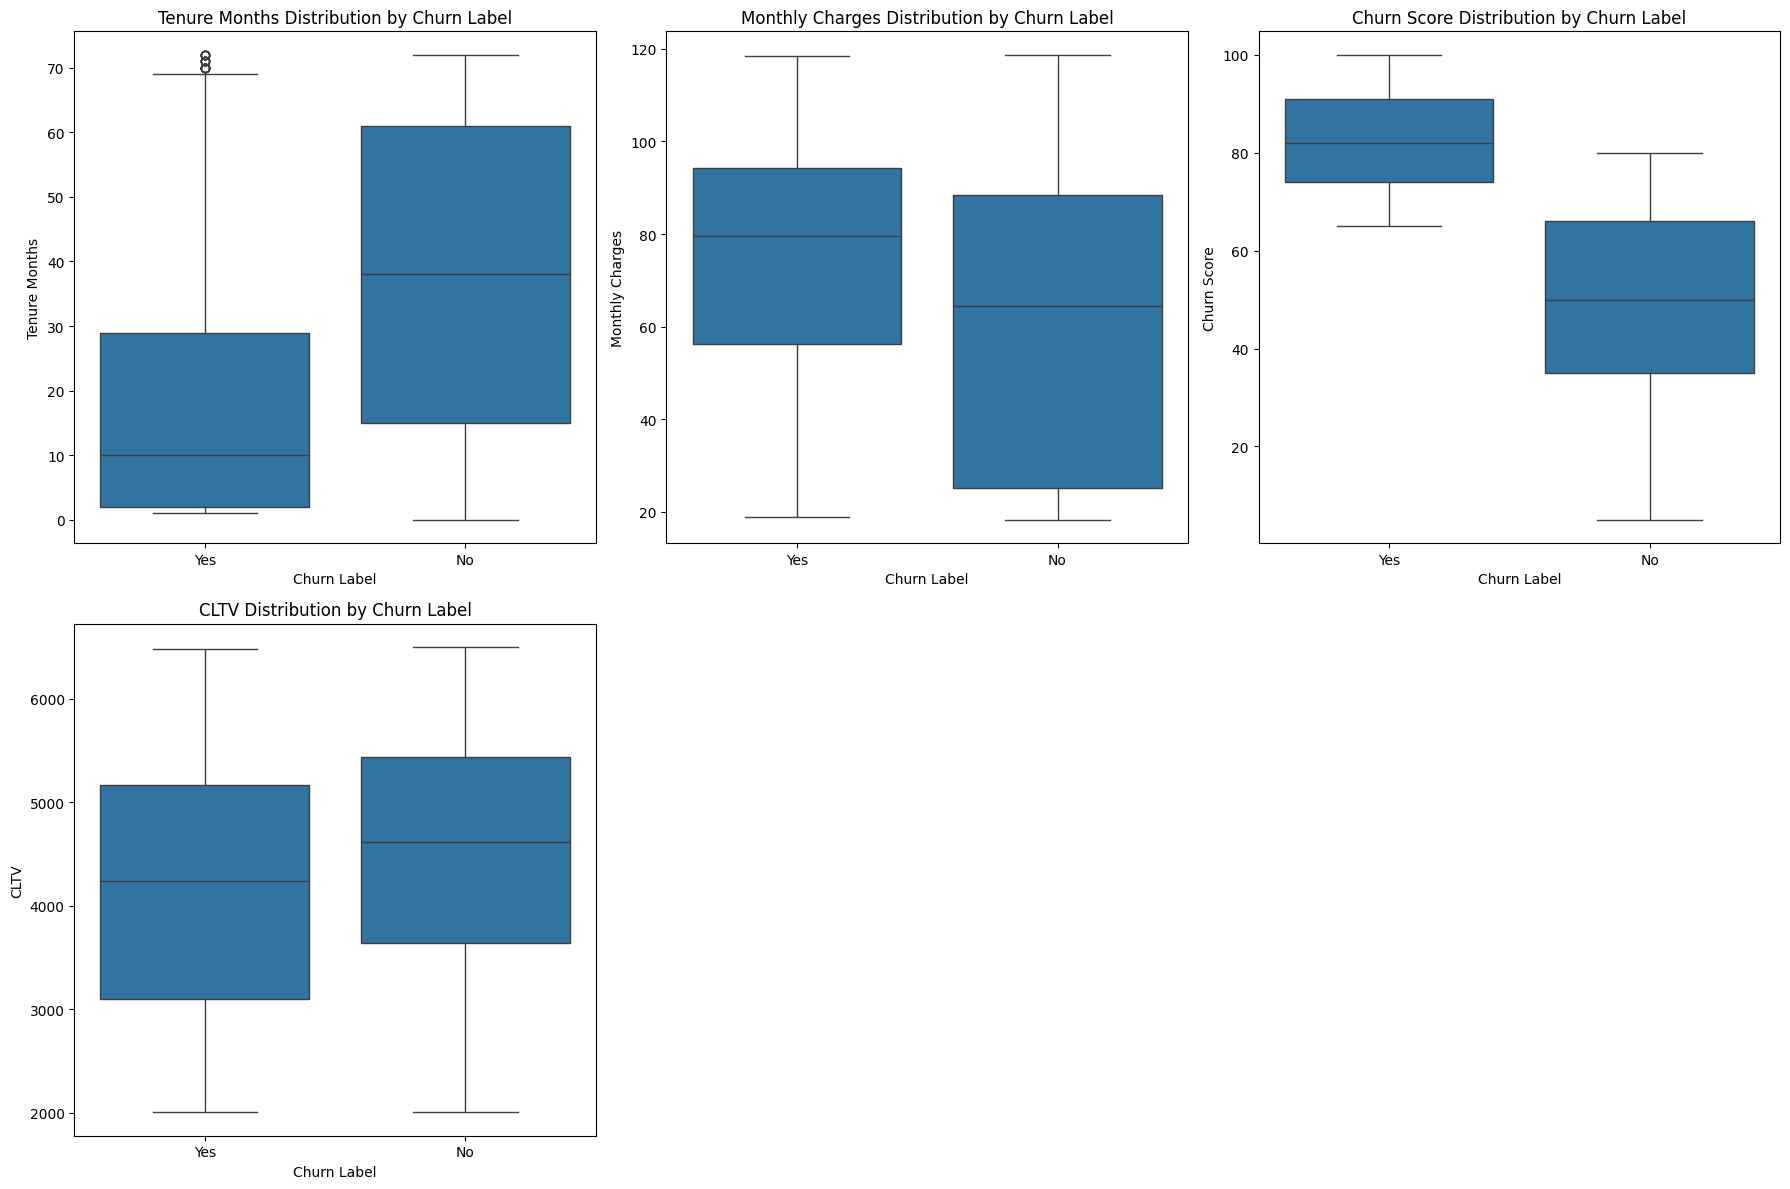

In [ ]:
# Plot numeric variables with respect to Churn label
numeric_vars = ['Tenure Months', 'Monthly Charges', 'Churn Score', 'CLTV']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    sns.boxplot(x='Churn Label', y=var, data=df, ax=axes[i])
    axes[i].set_title(f'{var} Distribution by Churn Label')

# Remove empty subplots (if any)
for j in range(len(numeric_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 5.2 Plot categorical variables with respect to Churn label

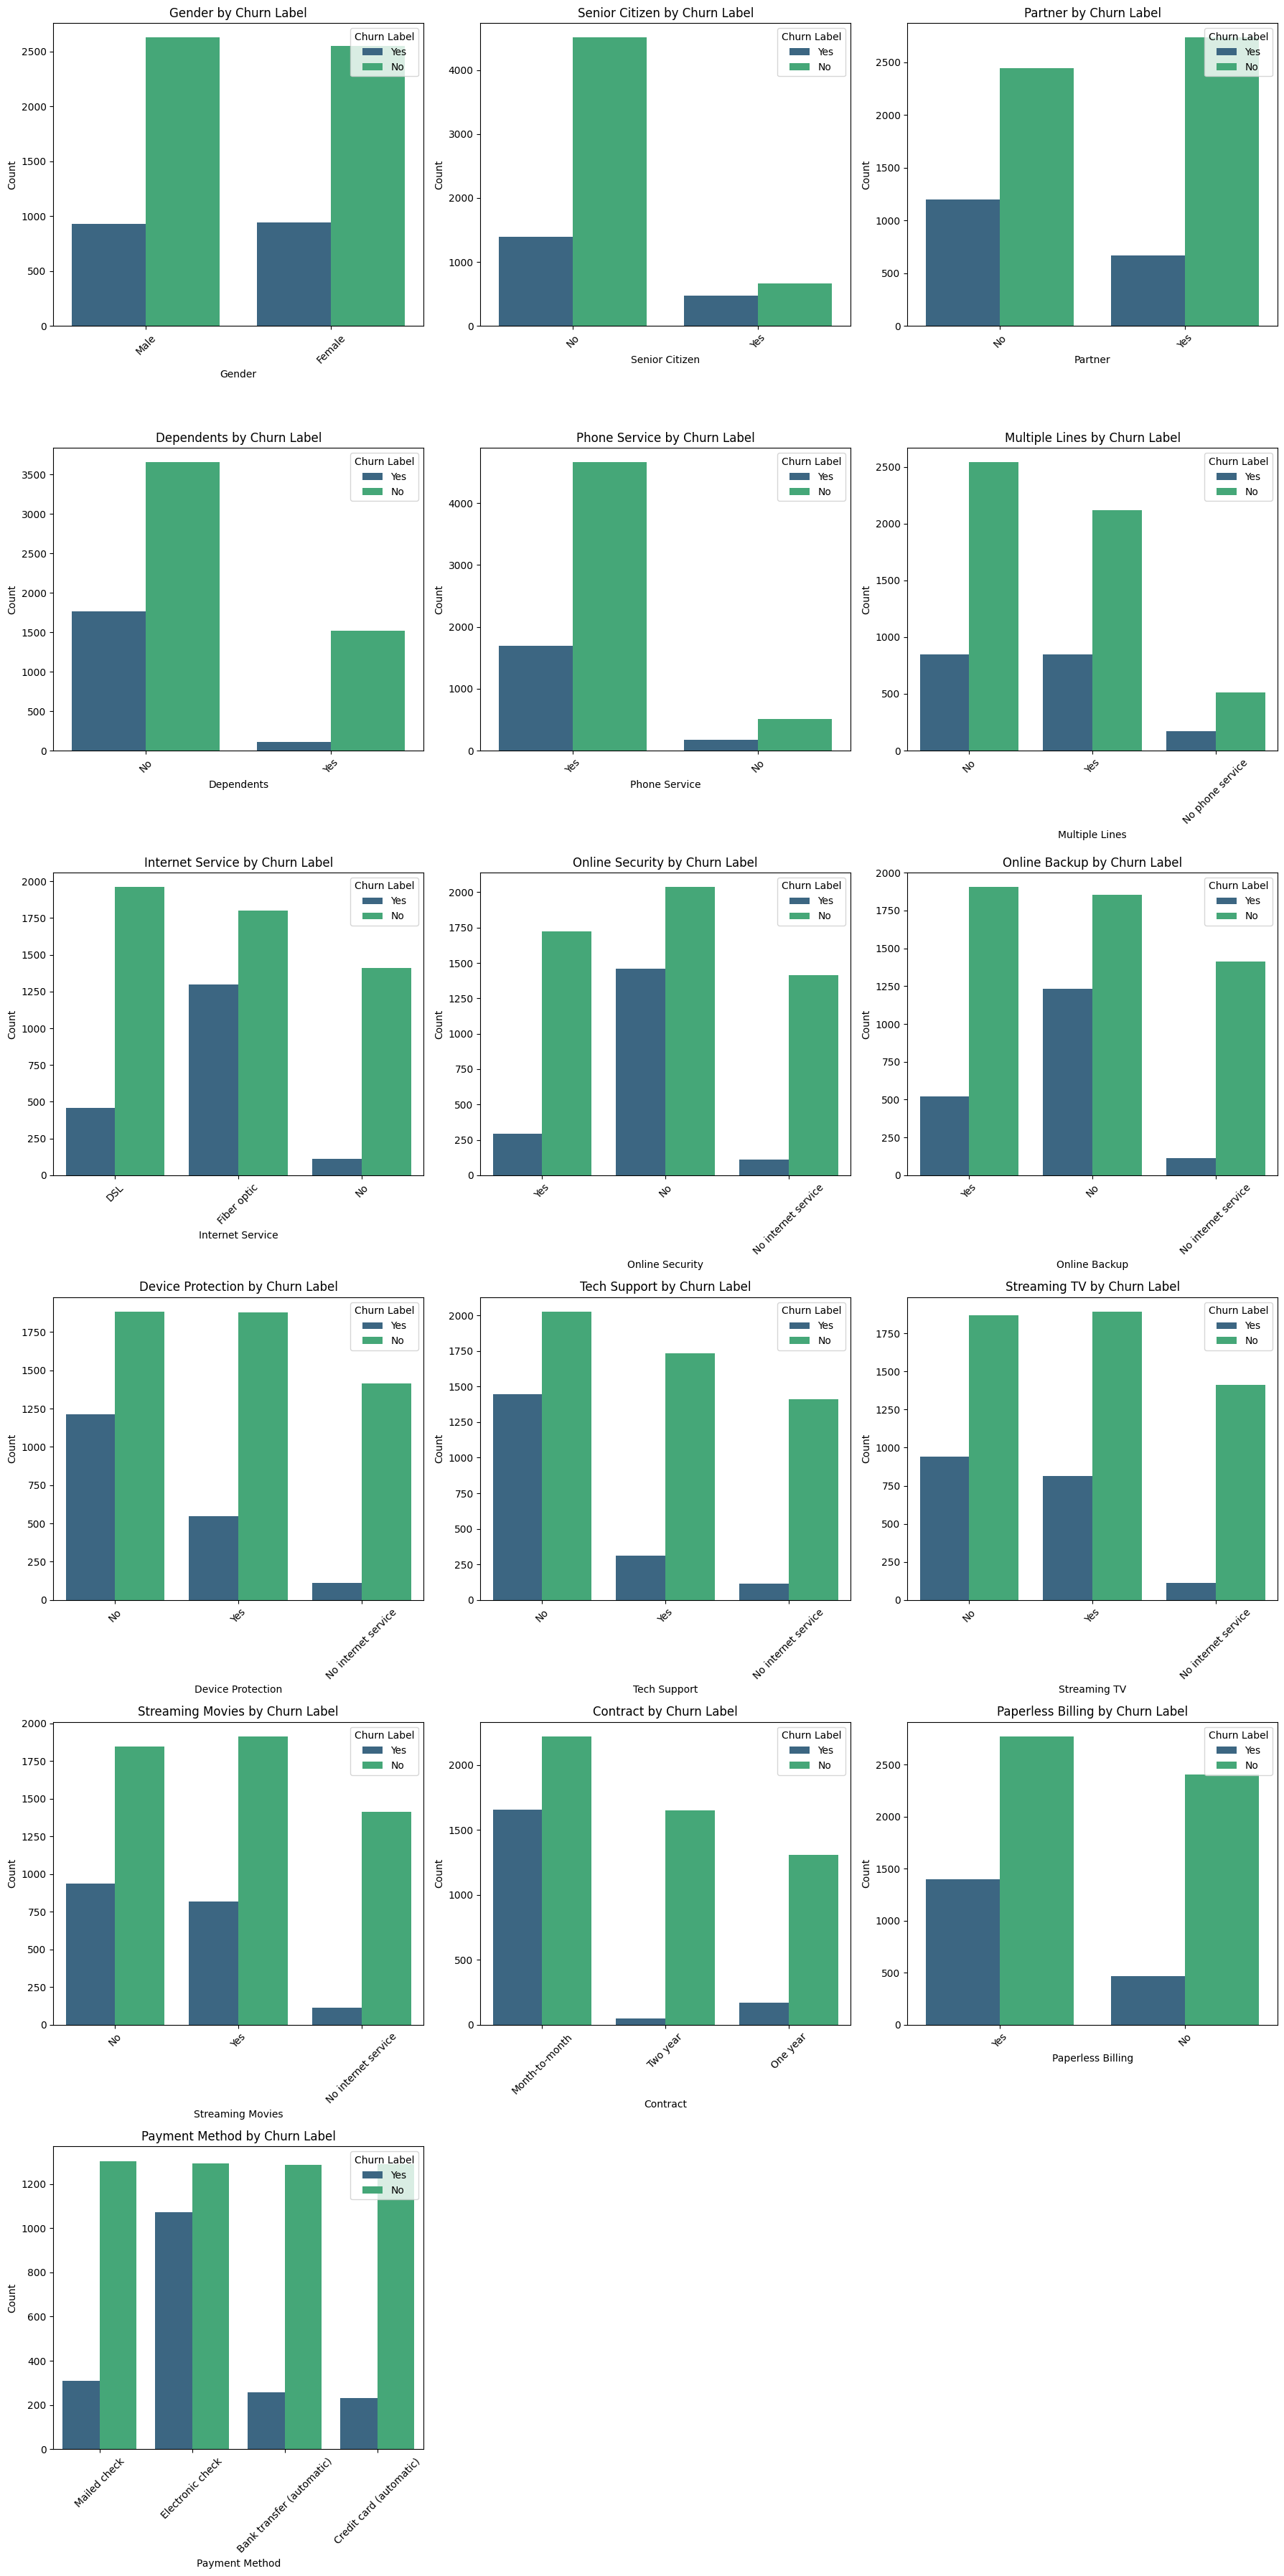

In [ ]:
# Plot categorical variables with respect to Churn label
categorical_vars = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method']

fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 36))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, hue='Churn Label', data=df, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{var} by Churn Label')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn Label', loc='upper right')

# Remove empty subplots (if any)
for j in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 5.3 Summary of Key Differences Between Churned and Non-Churned Customers

Based on the analysis of numerical and categorical variables, here are the distinct characteristics that differentiate churned customers from those who stayed:

**Numerical Variables:**

*   **Tenure Months**: Churned customers typically have **shorter tenures** (lower median 'Tenure Months') compared to non-churned customers. This suggests that newer customers are more susceptible to churn.
*   **Monthly Charges**: Customers with **higher 'Monthly Charges'** are more likely to churn. This could indicate dissatisfaction with the cost-to-value ratio or better offers from competitors.
*   **Churn Score**: As expected, churned customers have significantly **higher 'Churn Scores'**, which is a direct indicator of their likelihood to leave.
*   **CLTV (Customer Lifetime Value)**: Churned customers generally exhibit **lower 'CLTV'**, reflecting their reduced long-term value to the company.

**Categorical Variables:**

*   **Contract Type**: A large proportion of churned customers are on a **'Month-to-Month' contract**, while non-churned customers are more frequently on 'One Year' or 'Two Year' contracts. This highlights the importance of longer-term contracts for retention.
*   **Internet Service**: Customers with **'Fiber Optic' internet service** show a higher churn rate compared to those with DSL or no internet service. This might be due to higher expectations, competitive pricing in the fiber market, or service quality issues.
*   **Online Security & Tech Support**: Customers who **do NOT have 'Online Security' and 'Tech Support'** are more prone to churn. These services act as deterrents to churn, providing added value and security.
*   **Payment Method**: **'Electronic Check'** is a very common payment method among churned customers, suggesting potential issues or dissatisfaction with this payment process or the associated digital experience.
*   **Partner & Dependents**: Customers **without a 'Partner' or 'Dependents'** tend to churn more frequently. This could imply that individuals with household responsibilities might be less likely to switch providers due to the added inconvenience.
*   **Paperless Billing**: Customers using **'Paperless Billing'** show a slightly higher churn rate. This could be correlated with internet service usage and potentially other digital interactions where issues might arise.
*   **Senior Citizen**: 'Senior Citizens' appear to have a slightly higher churn rate, although this might need further investigation into specific service usage or support needs.

In summary, customers at a higher risk of churn are often newer, face higher monthly costs, are on flexible month-to-month contracts, lack crucial supplementary services like online security and tech support, and use electronic check payment. These insights can help in developing targeted retention strategies.

# 6.Data Preprocessing

## 6.1 Dropping unnecessary columns

In [ ]:
# Modify columns to drop to keep 'CustomerID' for export, but ensure it's not used as a feature
columns_to_drop = ['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Reason', 'CLTV', 'Churn Label', 'Churn Score']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

## 6.2 Converting 'Total Charges' to numerical variables

In [ ]:
# Since 'Total Charges' is object, we need to convert 'Total Charges' column to numeric, coercing errors to NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Check for missing values in the DataFrame
print(df.isnull().sum())

CustomerID            0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64


## 6.3 Handling missing values  in 'Total Charges' column

In [ ]:
# Delete rows with missing values in 'Total Charges' column
df=df.dropna(subset=['Total Charges'])
print(df.isnull().sum())

CustomerID           0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64


## 6.4 Splitting the data

In [ ]:
# Separate CustomerID before splitting to ensure it's not used as a feature
customer_ids = df['CustomerID']
X = df.drop(['Churn Value', 'CustomerID'], axis=1) # Drop CustomerID from features for training
y = df['Churn Value'].values

# Split the data, including CustomerIDs, to ensure correct mapping for test set
X_train, X_test, y_train, y_test, customer_ids_train, customer_ids_test = train_test_split(X, y, customer_ids, test_size=0.2, random_state=42)

## 6.5 Encoding Categorical Variables

In [ ]:
# Get categorical features
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

# OneHotEncoding for Nominal Categorical Features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # handle_unknown='ignore' to avoid errors during inference
X_train_ohe = encoder.fit_transform(X_train[cat_features])
X_test_ohe = encoder.transform(X_test[cat_features])

# Create DataFrames for encoded data
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=encoder.get_feature_names_out(cat_features), index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=encoder.get_feature_names_out(cat_features), index=X_test.index)

# Concatenate encoded features with numerical features
X_train = pd.concat([X_train.drop(cat_features, axis=1), X_train_ohe_df], axis=1)
X_test = pd.concat([X_test.drop(cat_features, axis=1), X_test_ohe_df], axis=1)

## 6.6 Standardization

In [ ]:
# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7.Building traditional classification models and evaluation

## 7.1 Logistic Regression model

In [ ]:
# Train a Logistic Regression model
model_lg = LogisticRegression(random_state=42)
model_lg.fit(X_train, y_train)

# Make predictions
y_pred = model_lg.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8123667377398721

Confusion Matrix:
 [[914  98]
 [166 229]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.63       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407



## 7.2 SVM model

In [ ]:
# Train a SVM model
model_svm = SVC()
model_svm.fit(X_train, y_train)

# Make predictions
y_pred = model_svm.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8031272210376688

Confusion Matrix:
 [[917  95]
 [182 213]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1012
           1       0.69      0.54      0.61       395

    accuracy                           0.80      1407
   macro avg       0.76      0.72      0.74      1407
weighted avg       0.79      0.80      0.80      1407



## 7.3 Random Forest Classifier

In [ ]:
# Train a Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=100 , oob_score = True, n_jobs = -1,
                                  random_state =50, max_features = 20,
                                  max_leaf_nodes = 30)
model_rf.fit(X_train, y_train)

# Make predictions
y_pred = model_rf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8088130774697939

Confusion Matrix:
 [[918  94]
 [175 220]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1012
           1       0.70      0.56      0.62       395

    accuracy                           0.81      1407
   macro avg       0.77      0.73      0.75      1407
weighted avg       0.80      0.81      0.80      1407



## 7.4 Comparison and Summary of Classification Models (7.1, 7.2, 7.3)

We have trained and evaluated three different classification models: Logistic Regression, Support Vector Machine (SVM), and Random Forest. Let's summarize their performance.

**1. Logistic Regression (Section 7.1)**
*   **Accuracy**: 0.812 (81.2%)
*   **Confusion Matrix**:
    *   True Negatives (TN): 914 (Correctly predicted non-churners)
    *   False Positives (FP): 98 (Incorrectly predicted churners)
    *   False Negatives (FN): 166 (Incorrectly predicted non-churners - missed churners)
    *   True Positives (TP): 229 (Correctly predicted churners)
*   **Classification Report (Class 1 - Churn)**:
    *   **Precision**: 0.70 (70% of predicted churners actually churned)
    *   **Recall**: 0.58 (58% of actual churners were identified)
    *   **F1-score**: 0.63

**2. Support Vector Machine (SVM) (Section 7.2)**
*   **Accuracy**: 0.803 (80.3%)
*   **Confusion Matrix**:
    *   TN: 917
    *   FP: 95
    *   FN: 182
    *   TP: 213
*   **Classification Report (Class 1 - Churn)**:
    *   **Precision**: 0.69
    *   **Recall**: 0.54
    *   **F1-score**: 0.61

**3. Random Forest Classifier (Section 7.3)**
*   **Accuracy**: 0.809 (80.9%)
*   **Confusion Matrix**:
    *   TN: 918
    *   FP: 94
    *   FN: 175
    *   TP: 220
*   **Classification Report (Class 1 - Churn)**:
    *   **Precision**: 0.70
    *   **Recall**: 0.56
    *   **F1-score**: 0.62

### Comparative Analysis

Overall, all three models achieved comparable accuracy scores, ranging from 80.3% to 81.2%. However, when focusing on the churn class (Class 1), which is typically the most critical for business decisions, we observe the following:

*   **Logistic Regression** showed the highest **Recall (0.58)** for the churn class, meaning it was slightly better at identifying actual churners among the three models. It also had a competitive precision of 0.70.
*   **Random Forest** achieved the best balance between False Positives (94) and False Negatives (175), resulting in a precision of 0.70 and a recall of 0.56. Its accuracy was also very close to that of Logistic Regression.
*   **SVM** had the lowest recall (0.54) for the churn class, indicating it missed more actual churners compared to the other two. While its precision (0.69) was similar, its overall F1-score was the lowest.

**In summary, for identifying churners (high recall), Logistic Regression performed marginally better. For a balance of precision and recall, Logistic Regression and Random Forest were very close, with Random Forest having slightly fewer false positives. Given its ensemble nature and typically strong performance on tabular data, Random Forest often provides good generalization capabilities.**

# 8.Exploring advanced algorithms: XGBoost, LightGBM and Neural Network

## 8.1 XGBoost Classifier

Now that we've simplified the Random Forest, let's explore other robust classification algorithms, starting with XGBoost. XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It's often a top performer in machine learning competitions due to its ability to handle various data types, missing values, and complex relationships.

We will train an XGBoost classifier, taking into account the class imbalance, and evaluate its performance against the tuned Random Forest.

In [ ]:
import xgboost as xgb

print("Starting XGBoost Classifier Training (without 'Churn Score')")

# Initialize the XGBoost Classifier
# Using 'scale_pos_weight' to handle class imbalance, which is equivalent to 'class_weight'
# Calculate the ratio of negative class to positive class
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight_value = neg_count / pos_count

xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_value # Handle class imbalance
)

# Train the model
xgb_classifier.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
print("\n--- XGBoost Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Starting XGBoost Classifier Training (without 'Churn Score')


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:20:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Model Evaluation ---
Accuracy: 0.7661691542288557

Confusion Matrix:
 [[803 209]
 [120 275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.79      0.83      1012
           1       0.57      0.70      0.63       395

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.77      0.77      1407



## 8.2 LightGBM Classifier

Following XGBoost, let's explore another powerful gradient boosting framework: LightGBM (Light Gradient Boosting Machine). LightGBM is designed to be highly efficient and scalable, especially for large datasets. It often outperforms XGBoost in terms of training speed and can achieve comparable predictive accuracy.

We will train a LightGBM classifier, similar to XGBoost, ensuring we handle class imbalance by setting `is_unbalance=True` or `scale_pos_weight` in its parameters. We will then evaluate its performance and compare it to the Random Forest and XGBoost models.

In [ ]:
import lightgbm as lgb

print("Starting LightGBM Classifier Training (without 'Churn Score')")

# Initialize the LightGBM Classifier
# Using 'scale_pos_weight' to handle class imbalance
# The calculation for neg_count and pos_count is already available from XGBoost step.

lgbm_classifier = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    is_unbalance=True, # Automatically handles imbalanced dataset
    # Alternatively, use scale_pos_weight=scale_pos_weight_value, calculated previously
    random_state=42,
    n_jobs=-1
)

# Train the model
lgbm_classifier.fit(X_train, y_train)

# Make predictions
y_pred_lgbm = lgbm_classifier.predict(X_test)

# Evaluate the model
print("\n--- LightGBM Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))

Starting LightGBM Classifier Training (without 'Churn Score')
[LightGBM] [Info] Number of positive: 1474, number of negative: 4151
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 712
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.262044 -> initscore=-1.035369
[LightGBM] [Info] Start training from score -1.035369

--- LightGBM Model Evaluation ---
Accuracy: 0.7640369580668088

Confusion Matrix:
 [[772 240]
 [ 92 303]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1012
           1       0.56      0.77      0.65       395

    accuracy                           0.76      1407
   macro avg       0.73      0.76 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 8.3 Neural network model

In [ ]:
from tensorflow import keras
from sklearn.utils import class_weight


print("Starting Simple Neural Network Training (without 'Churn Score')")

Starting Simple Neural Network Training (without 'Churn Score')


In [ ]:
# Define the neural network model
model_nn = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)), # Input layer matches number of features
    keras.layers.Dense(128, activation='relu'), # Hidden layer with 128 neurons and ReLU activation
    keras.layers.Dropout(0.3), # Dropout for regularization
    keras.layers.Dense(64, activation='relu'),  # Another hidden layer
    keras.layers.Dropout(0.3), # Dropout for regularization
    keras.layers.Dense(1, activation='sigmoid')  # Output layer with sigmoid for binary classification
])

# Compile the model
model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Calculate class weights for imbalance handling
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {i : class_weights[i] for i in range(len(class_weights))}

print("\nClass weights for training:", class_weights_dict)

# Train the model
history = model_nn.fit(
    X_train,
    y_train,
    epochs=50, # Number of epochs can be adjusted
    batch_size=32,
    validation_split=0.2, # Use a validation split to monitor performance during training
    class_weight=class_weights_dict,
    verbose=0 # Set verbose to 1 or 2 for more training output
)

print("\n--- Simple Neural Network Model Evaluation ---")

# Make predictions (probabilities)
y_pred_proba_nn = model_nn.predict(X_test)
# Convert probabilities to binary predictions
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



Class weights for training: {0: np.float64(0.6775475788966514), 1: np.float64(1.9080732700135685)}

--- Simple Neural Network Model Evaluation (without 'Churn Score') ---
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.7526652452025586

Confusion Matrix:
 [[746 266]
 [ 82 313]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1012
           1       0.54      0.79      0.64       395

    accuracy                           0.75      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.75      0.76      1407



## 8.4 Comparison and Summary of XGBoost, LightGBM, and Neural Network Models

We have trained and evaluated three additional classification models: XGBoost, LightGBM, and a Simple Neural Network. Let's summarize their performance and compare them.

**1. XGBoost Classifier (Section 8.1)**
*   **Accuracy**: 0.766 (76.6%)
*   **Confusion Matrix**:
    *   True Negatives (TN): 803
    *   False Positives (FP): 209
    *   False Negatives (FN): 120
    *   True Positives (TP): 275
*   **Classification Report (Class 1 - Churn)**:
    *   **Precision**: 0.57 (57% of predicted churners actually churned)
    *   **Recall**: 0.70 (70% of actual churners were identified)
    *   **F1-score**: 0.63

**2. LightGBM Classifier (Section 8.2)**
*   **Accuracy**: 0.764 (76.4%)
*   **Confusion Matrix**:
    *   TN: 772
    *   FP: 240
    *   FN: 92
    *   TP: 303
*   **Classification Report (Class 1 - Churn)**:
    *   **Precision**: 0.56
    *   **Recall**: 0.77 (77% of actual churners were identified)
    *   **F1-score**: 0.65

**3. Simple Neural Network (Section 8.3)**
*   **Accuracy**: 0.753 (75.3%)
*   **Confusion Matrix**:
    *   TN: 746
    *   False Positives (FP): 266
    *   False Negatives (FN): 82
    *   True Positives (TP): 313
*   **Classification Report (Class 1 - Churn)**:
    *   **Precision**: 0.54 (54% of predicted churners actually churned)
    *   **Recall**: 0.79 (79% of actual churners were identified)
    *   **F1-score**: 0.64

### Comparative Analysis of Advanced Models

All three advanced models (XGBoost, LightGBM, and Neural Network) show varying overall accuracy, with LightGBM and XGBoost around 76% and the Neural Network at 75.3%. However, there are notable differences when focusing on churn prediction (Class 1), especially regarding the trade-off between precision and recall.

*   **Recall for Churn**: The Neural Network achieved the highest recall at 0.79, meaning it was the best at identifying actual churners. LightGBM followed closely at 0.77, and XGBoost at 0.70. All three models demonstrate a significantly higher recall for the churn class compared to the earlier Logistic Regression, SVM, and Random Forest models (which were in the range of 0.54-0.58).

*   **Precision for Churn**: Correspondingly, the precision for these models is lower than the earlier traditional models. The Neural Network has the lowest precision at 0.54, followed by LightGBM (0.56) and XGBoost (0.57). This indicates that while they catch more churners, they also have a higher rate of false positives (classifying non-churners as churners).

*   **F1-Score for Churn**: LightGBM achieved the highest F1-score for the churn class (0.65), suggesting a slightly better balance between precision and recall, followed by the Neural Network (0.64) and XGBoost (0.63).

**In summary, if the primary business objective is to identify as many actual churners as possible (maximizing recall), the Simple Neural Network appears to be the most promising, despite a higher number of false positives. LightGBM offers the best balance of precision and recall (highest F1-score) among these advanced models. XGBoost also offers a good balance. These models have effectively leveraged their capabilities to better identify the minority churn class.**

### Why Neural Network Recall Might Change Across Runtime Restarts:

Neural networks inherently involve stochastic processes during training. When you restart the runtime, the internal states of random number generators for libraries like TensorFlow/Keras and NumPy are reset. Unless explicitly set, this can lead to variations in:

1.  **Weight Initialization**: The initial random weights of the neural network's layers will be different in each run.
2.  **Data Shuffling**: The order in which data batches are presented to the network during training will vary, especially if no fixed seed is used for shuffling.
3.  **Dropout Layers**: Dropout randomly deactivates neurons during training. If the random seed controlling dropout is not fixed, the specific neurons dropped will change, influencing the learning process.

These small differences can lead the neural network to converge to slightly different local minima in the loss landscape, resulting in variations in the final model's performance metrics, including recall.

# 9.Export prediction csv file using the LightGBM model

In [ ]:
# Make predictions (probabilities) using the LightGBM model
y_pred_proba_lgbm = lgbm_classifier.predict_proba(X_test)[:, 1]

# Convert probabilities to binary predictions (using 0.5 as threshold)
y_pred_lgbm_binary = (y_pred_proba_lgbm > 0.5).astype(int)

# Create a DataFrame to store actual, predicted values, and CustomerID
predictions_df_lgbm = pd.DataFrame({
    'CustomerID': customer_ids_test,
    'Actual_Churn': y_test,
    'Predicted_Churn': y_pred_lgbm_binary,
    'Predicted_Probability_Churn': y_pred_proba_lgbm
})

# Reset index to ensure CustomerID aligns correctly
predictions_df_lgbm = predictions_df_lgbm.reset_index(drop=True)

# Save the DataFrame to a CSV file
predictions_df_lgbm.to_csv('lgbm_churn_predictions.csv', index=False)

print("LightGBM predictions saved to 'lgbm_churn_predictions.csv'")
display(predictions_df_lgbm.head(20))

LightGBM predictions saved to 'lgbm_churn_predictions.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,CustomerID,Actual_Churn,Predicted_Churn,Predicted_Probability_Churn
0,8098-TDCBU,0,0,0.053488
1,9388-ZEYVT,0,0,0.153168
2,1818-ESQMW,0,1,0.715687
3,7941-RCJOW,0,0,0.003164
4,2065-MMKGR,0,0,0.428214
5,7321-KKSDU,0,0,0.000813
6,9153-BTBVV,0,0,0.002428
7,1178-PZGAB,0,0,0.073565
8,8383-SGHJU,0,0,0.094309
9,0378-TOVMS,1,1,0.811067


# 10.Conclusion and Recommendations

Throughout this notebook, we embarked on a journey to build and evaluate various machine learning models for customer churn prediction. Our goal was to identify the most effective model for accurately predicting customer churn, particularly focusing on maximizing the identification of actual churners (recall for the churn class).


### Key Insights and Recommendations:

*   **Focus on Recall**: The business objective of identifying actual churners (to proactively implement retention strategies) makes **recall for the churn class** a paramount metric. The advanced models (XGBoost, LightGBM, and Neural Network) significantly outperformed the traditional models in this regard, achieving recall scores in the 0.70-0.79 range, compared to 0.54-0.58 for traditional models.

*   **Trade-off between Precision and Recall**: While the advanced models achieved higher recall, they generally exhibited lower precision for the churn class. This means they are better at catching churners but also classify more non-churners as churners (false positives). The optimal balance depends on the cost associated with false positives vs. false negatives. For churn, missing a churner (false negative) is often more costly than offering a retention incentive to a loyal customer (false positive).

*   **Neural Network Achieves Highest Recall**: The Simple Neural Network achieved the highest recall (0.79) for the churn class, making it the most effective at identifying potential churners in this dataset. However, this came with the lowest precision (0.54) and F1-score (0.64) among the advanced models.

*   **LightGBM Offers Best Balance**: LightGBM achieved a strong recall (0.77) while maintaining a better balance with precision (0.56), resulting in the highest F1-score (0.65) among all models. This indicates a good overall performance for identifying churners with a reasonable level of false positives.

*   **Interpretability vs. Performance**: Traditional models like Logistic Regression offer better interpretability, but at the cost of lower churn recall. If understanding *why* a customer churns is as important as predicting it, feature importance analysis from models like XGBoost or a simplified Random Forest would be beneficial.

*   **Final Recommendation**: Given the emphasis on identifying actual churners, and considering the trade-offs, **LightGBM** emerges as the strongest all-around candidate. It offers a highly competitive recall and the best F1-score for the churn class, is computationally efficient, and robust. The Simple Neural Network is an excellent alternative if maximizing recall is the absolute priority, and the business can tolerate a higher number of false positives.

### Strategic Recommendations for Business Action:

1.  **Deploy LightGBM (or Neural Network)**: Implement the LightGBM model for real-time churn prediction, or the Neural Network if the highest possible recall is paramount. These models will enable the identification of a large proportion of at-risk customers.
2.  **Targeted Retention Programs**: Focus retention efforts on customers flagged as high-risk by the model. These programs can include personalized offers, proactive customer service outreach, or addressing specific pain points (e.g., high monthly charges, lack of tech support).
3.  **Monitor False Positives**: While high recall is crucial, it's also important to monitor false positives. If the cost of offering incentives to non-churners becomes too high, a slight adjustment to the model's prediction threshold or further tuning might be considered.
4.  **Continuous Monitoring and Retraining**: Churn drivers can evolve. The model should be continuously monitored for performance degradation and retrained periodically with new data to ensure its effectiveness.

By leveraging these models and insights, the Telco company can proactively reduce customer churn, leading to improved customer lifetime value and sustained growth.

# 11.Export Notebook to HTML

In [ ]:
!pip install nbconvert

In [32]:
# Convert the original notebook to HTML
!jupyter nbconvert --to html "/content/drive/My Drive/Work/Colab Notebooks/Projects in Resume/Telco churn prediction_Github.ipynb" --output "telco_churn_prediction.html"

[NbConvertApp] WARNING | pattern '/content/drive/My Drive/Work/Colab Notebooks/Projects in Resume/Telco churn prediction_Github.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions ins

In [ ]:
# Download HTML file
from google.colab import files

files.download('/content/drive/My Drive/Work/Colab Notebooks/Projects in Resume/telco_churn_prediction.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>